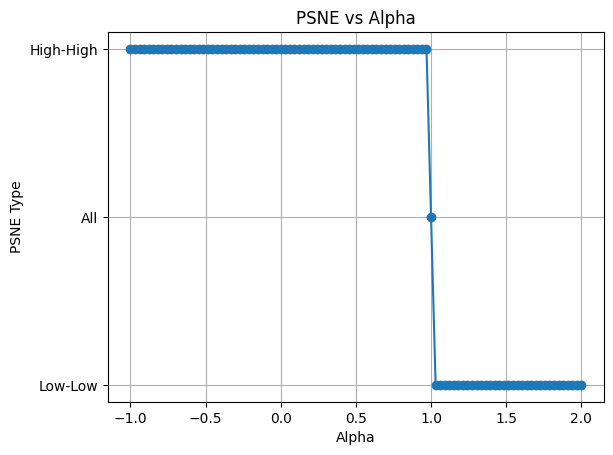

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Strategy labels
strategies = [1, 2, 3]

def U1(x, y, alpha):
    return x - alpha * (x + y)

def U2(x, y, alpha):
    return y - alpha * (x + y)

def find_psne(alpha):
    psne = []

    for x in strategies:
        for y in strategies:
            u1 = U1(x, y, alpha)
            u1_best = max(U1(x_alt, y, alpha) for x_alt in strategies)

            u2 = U2(x, y, alpha)
            u2_best = max(U2(x, y_alt, alpha) for y_alt in strategies)

            if u1 == u1_best and u2 == u2_best:
                psne.append((x, y))

    return psne

def classify(psne):
    if len(psne) == 9:
        return 1   # All equilibria
    elif psne == [(3,3)]:
        return 2   # High-High
    elif psne == [(1,1)]:
        return 0   # Low-Low
    else:
        return -1  # (just in case)

# Alpha range (smooth curve)
alpha_values = np.linspace(-1, 2, 100)
categories = []

for alpha in alpha_values:
    psne = find_psne(alpha)
    categories.append(classify(psne))

# Plot
plt.figure()
plt.plot(alpha_values, categories, marker='o')

# Custom y-axis labels
plt.yticks([0, 1, 2], ['Low-Low', 'All', 'High-High'])

plt.xlabel('Alpha')
plt.ylabel('PSNE Type')
plt.title('PSNE vs Alpha')
plt.grid()

plt.show()

In [2]:
import numpy as np
from scipy.optimize import linprog

# Rows: Firm A
# Columns: Firm B

#r1: Low
#r2: Medium
#r3: High

#c1: Low
#c2: Medium 
#c3: High

strategy_labels = ['Low', 'Medium', 'High']


payoff_matrix = np.array([
                [0, -0.5, -1],
                [0.5, 0, -0.5],
                [1, 0.5, 0]
                        ])


def find_saddle_points(matrix):
    # Find minimum of each row
    row_mins = np.min(matrix, axis=1)
    
    # Find maximum of each column
    col_maxes = np.max(matrix, axis=0)
    
    saddle_point = False
    saddle_points = []
    
    for i in range(len(row_mins)):
        for j in range(len(col_maxes)):
            if row_mins[i] == col_maxes[j]:
                print(f"Saddle point found at row {i+1}, column {j+1} with value {row_mins[i]}")
                saddle_points.append((i, j))
                saddle_point = True
    
    if not saddle_point:
        print("No saddle point found")
    
    return saddle_points

def PSNE(matrix):
    saddle_points = find_saddle_points(matrix)
    
    for i in range(len(saddle_points)):
        row = saddle_points[i][0]
        col = saddle_points[i][1]
        
        print(f"Pure State Nash Equilibrium found at row {row+1} ({strategy_labels[row]}), column {col+1} ({strategy_labels[col]}) with payoff {matrix[row][col]}")


find_saddle_points(payoff_matrix)
PSNE(payoff_matrix)


Saddle point found at row 3, column 3 with value 0.0
Saddle point found at row 3, column 3 with value 0.0
Pure State Nash Equilibrium found at row 3 (High), column 3 (High) with payoff 0.0


In [3]:
n = 3  # number of strategies
# Objective: maximize Z
# z ≤ sum(p_i * A_ij), for each i given j

def player_a_lp(payoff_matrix):
    A_ub = []
    b_ub = []

    for j in range(n):
        row = list(payoff_matrix[:, j]) + [-1]  # sum(p_i A_ij) - z ≥ 0
        A_ub.append([-x for x in row])  # convert to ≤ form
        b_ub.append(0)  # z - sum(p_i A_ij) <= 0


    # For summation constraint: sum(p_i) = 1
    A_eq = [[1]*n + [0]]
    b_eq = [1]
    # maximization of Z
    c = [0]*n + [-1]

    #pi belongs to [0,1]
    #z belongs to [-inf, inf]
    bounds = [(0,1)]*n + [(None,None)]

    res = linprog(c, A_ub=A_ub, b_ub=b_ub,
                A_eq=A_eq, b_eq=b_eq,
                bounds=bounds)

    # print("p:", res.x[:-1])
    return res.x[:-1], res.x[-1]

def player_b_lp(payoff_matrix):
    A_ub = []
    b_ub = []
    for i in range(n):
        row = list(payoff_matrix[i, :]) + [-1]  # sum(p_i A_ij) - z ≥ 0
        A_ub.append([x for x in row])  # convert to ≤ form
        b_ub.append(0)  # z - sum(p_i A_ij) <= 0

    # For summation constraint: sum(p_i) = 1
    A_eq = [[1]*n + [0]]
    b_eq = [1]
    # maximization of Z
    c = [0]*n + [1]

    #pi belongs to [0,1]
    #z belongs to [-inf, inf]
    bounds = [(0,1)]*n + [(None,None)]

    res = linprog(c, A_ub=A_ub, b_ub=b_ub,
                A_eq=A_eq, b_eq=b_eq,
                bounds=bounds)

    # print("p:", res.x[:-1])
    return res.x[:-1], -1*res.x[-1]

print("Player A's mixed strategy:", player_a_lp(payoff_matrix)[0], "with value:", player_a_lp(payoff_matrix)[1])
print("Player B's mixed strategy:", player_b_lp(payoff_matrix)[0], "with value:", player_b_lp(payoff_matrix)[1])

Player A's mixed strategy: [0. 0. 1.] with value: -0.0
Player B's mixed strategy: [0. 0. 1.] with value: 0.0


Indifference Method

In [4]:
import numpy as np
import itertools

def find_msne(A, B, tol=1e-6):
    n = A.shape[0]
    equilibria = []

    strategies = list(range(n))

    # Try all support sizes
    for k in range(1, n+1):
        supports_A = list(itertools.combinations(strategies, k))
        supports_B = list(itertools.combinations(strategies, k))

        for SA in supports_A:
            for SB in supports_B:

                SA = list(SA)
                SB = list(SB)

                # Solve for Player A probabilities (p)
                try:
                    M = []
                    for i in SA:
                        row = [A[i][j] for j in SB]
                        M.append(row)

                    M = np.array(M)

                    # Make rows equal → subtract first row
                    M_diff = M[1:] - M[0]

                    # Add probability sum constraint
                    ones = np.ones((1, len(SB)))
                    M_eq = np.vstack([M_diff, ones])
                    b_eq = np.array([0]*(len(SA)-1) + [1])

                    q = np.linalg.lstsq(M_eq, b_eq, rcond=None)[0]

                    if np.any(q < -tol):
                        continue

                    # Solve for Player B probabilities (p)
                    N = []
                    for j in SB:
                        row = [B[i][j] for i in SA]
                        N.append(row)

                    N = np.array(N).T

                    N_diff = N[1:] - N[0]

                    ones = np.ones((1, len(SA)))
                    N_eq = np.vstack([N_diff, ones])
                    b_eq = np.array([0]*(len(SB)-1) + [1])

                    p = np.linalg.lstsq(N_eq, b_eq, rcond=None)[0]

                    if np.any(p < -tol):
                        continue

                    # Normalize (clean small negatives)
                    p = np.maximum(p, 0)
                    q = np.maximum(q, 0)
                    p = p / np.sum(p)
                    q = q / np.sum(q)

                    # Build full strategy vectors
                    full_p = np.zeros(n)
                    full_q = np.zeros(n)

                    for idx, val in zip(SA, p):
                        full_p[idx] = val
                    for idx, val in zip(SB, q):
                        full_q[idx] = val

                    # Verify best response condition
                    payoff_A = A @ full_q
                    payoff_B = full_p @ B

                    max_A = np.max(payoff_A)
                    max_B = np.max(payoff_B)

                    if all(abs(payoff_A[i] - max_A) < tol for i in SA) and \
                       all(abs(payoff_B[j] - max_B) < tol for j in SB):

                        equilibria.append((full_p, full_q))

                except np.linalg.LinAlgError:
                    continue

    return equilibria

def build_utility_matrices(alpha, rates=(1, 2, 3)):
    """
    alpha: congestion weight
    rates: numerical values for (Low, Medium, High)
           default = (1, 2, 3)
    
    Returns:
        U1, U2 -> 3x3 numpy arrays
    """
    n = len(rates)
    
    U1 = np.zeros((n, n))
    U2 = np.zeros((n, n))
    
    for i, x in enumerate(rates):      # Host 1 strategy
        for j, y in enumerate(rates):  # Host 2 strategy
            U1[i, j] = x - alpha * (x + y)
            U2[i, j] = y - alpha * (x + y)
    
    return U1, U2

U1, U2 = build_utility_matrices(alpha = 1.1)  
find_msne(U1, U2)

[(array([1., 0., 0.]), array([1., 0., 0.]))]

In [5]:
def expected_payoff(U1, U2, p, q):
    """
    Computes expected payoff given mixed strategies
    """
    v1 = p @ U1 @ q
    v2 = p @ U2 @ q
    return v1, v2

In [6]:
import numpy as np

def simulate_game(U1, U2, p, q, T=10000):
    n = len(p)
    
    payoffs_1 = []
    payoffs_2 = []
    
    avg_1 = []
    avg_2 = []
    
    cum1 = 0
    cum2 = 0
    
    for t in range(1, T+1):
        # sample strategies
        i = np.random.choice(n, p=p)
        j = np.random.choice(n, p=q)
        
        u1 = U1[i, j]
        u2 = U2[i, j]
        
        cum1 += u1
        cum2 += u2
        
        payoffs_1.append(u1)
        payoffs_2.append(u2)
        
        avg_1.append(cum1 / t)
        avg_2.append(cum2 / t)
    
    return avg_1, avg_2

In [7]:
import matplotlib.pyplot as plt

def plot_convergence(avg_1, avg_2, v1, v2):
    plt.figure()
    
    plt.plot(avg_1, label="Empirical Player 1")
    plt.plot(avg_2, label="Empirical Player 2")
    
    plt.axhline(y=v1, linestyle='--', label="Theoretical P1")
    plt.axhline(y=v2, linestyle='--', label="Theoretical P2")
    
    plt.xlabel("Iterations")
    plt.ylabel("Average Payoff")
    plt.title("Convergence to Nash Equilibrium Payoff")
    
    plt.legend()
    plt.show()

[(array([1., 0., 0.]), array([1., 0., 0.])), (array([1., 0., 0.]), array([0., 1., 0.])), (array([1., 0., 0.]), array([0., 0., 1.])), (array([0., 1., 0.]), array([1., 0., 0.])), (array([0., 1., 0.]), array([0., 1., 0.])), (array([0., 1., 0.]), array([0., 0., 1.])), (array([0., 0., 1.]), array([1., 0., 0.])), (array([0., 0., 1.]), array([0., 1., 0.])), (array([0., 0., 1.]), array([0., 0., 1.])), (array([0.5, 0.5, 0. ]), array([0.5, 0.5, 0. ])), (array([0.5, 0.5, 0. ]), array([0.5, 0. , 0.5])), (array([0.5, 0.5, 0. ]), array([0. , 0.5, 0.5])), (array([0.5, 0. , 0.5]), array([0.5, 0.5, 0. ])), (array([0.5, 0. , 0.5]), array([0.5, 0. , 0.5])), (array([0.5, 0. , 0.5]), array([0. , 0.5, 0.5])), (array([0. , 0.5, 0.5]), array([0.5, 0.5, 0. ])), (array([0. , 0.5, 0.5]), array([0.5, 0. , 0.5])), (array([0. , 0.5, 0.5]), array([0. , 0.5, 0.5])), (array([0.33333333, 0.33333333, 0.33333333]), array([0.33333333, 0.33333333, 0.33333333]))]
MSNE Strategies:
Player 1: [0.33333333 0.33333333 0.33333333]

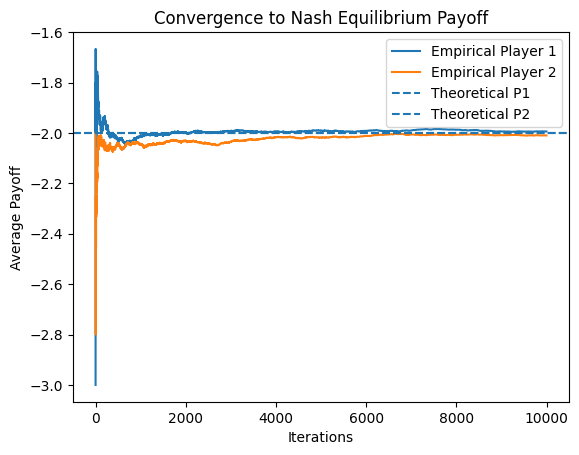

In [8]:
U1, U2 = build_utility_matrices(alpha=1)

eqs = find_msne(U1, U2)

print(eqs)
# take first equilibrium
p, q = eqs[-1]

print("MSNE Strategies:")
print("Player 1:", p)
print("Player 2:", q)

# theoretical payoff
v1, v2 = expected_payoff(U1, U2, p, q)
print("\nTheoretical Payoffs:", v1, v2)

# simulate
avg_1, avg_2 = simulate_game(U1, U2, p, q, T=10000)

# plot
plot_convergence(avg_1, avg_2, v1, v2)